In [298]:
import pandas as pd
from text import import_text
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
import shutil
import networkx as nx
from collections import Counter

#Import bertopic
from umap import UMAP
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

# 0) Import data

In [29]:
# Import and filter metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")

In [261]:
#Create_backup:
shutil.copy("../data/document_data_clean_filtered.csv", "../data/document_data_clean_filtered_auto_backup.csv")
# Save df:
df.to_csv("../data/document_data_clean_filtered.csv", index=False)

In [30]:
#docs_text: list containing each sentence where "Eucalyptus" appears in
#docs_ark: list containing the "ark" id of the document for the corresponding sentence
docs_text = []
docs_ark = []
for doc in df["ark"].to_list():
    text_cleaned = import_text(doc, context="sentence", size=0, separated_contexts=True)
    docs_text.extend(text_cleaned)
    docs_ark.extend([doc] * len(text_cleaned))

In [31]:
#Save docs_text and docs_ark
with open("extracted_docs_list.pkl", "wb") as fp:
    pickle.dump((docs_text, docs_ark), fp)

In [32]:
#Load docs_text and docs_ark without having to extract them
with open("extracted_docs_list.pkl", "rb") as fp:
    docs_text, docs_ark = pickle.load(fp)

# 1) Initialize Topic Model

In [33]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(ctfidf_model=ctfidf_model, language="multilingual", min_topic_size=50)
topic_model.umap_model.random_state = 1337
topic_model.umap_model.init = "random"

topics, probs = topic_model.fit_transform(docs_text)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8248.10it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
#Reduce outliers
less_outliers_topics = topic_model.reduce_outliers(docs_text, topics)

In [37]:
topic_number = 0
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 0


[('australie', np.float64(0.2670035373022027)),
 ('tasmanie', np.float64(0.22279501986674805)),
 ('australiens', np.float64(0.1889388426406636)),
 ('australien', np.float64(0.18711266502492166)),
 ('gum', np.float64(0.17467473335014924)),
 ('australiennes', np.float64(0.1661937260326378)),
 ('galles', np.float64(0.1652424873734348)),
 ('sud', np.float64(0.1603337426263505)),
 ('sydney', np.float64(0.15665693437573777)),
 ('victoria', np.float64(0.15499086580703225))]

In [76]:
#Save topic_model
with open("topic_model.pkl", "wb") as fp:
    pickle.dump((docs_text, docs_ark), fp)

In [77]:
#Load topic_model
with open("topic_model.pkl", "rb") as fp:
    docs_text, docs_ark = pickle.load(fp)

## 1.1) Assign Meta-topics:

In [248]:
metatopics = {
    "Géographie": [0, 1, 39, 43, 47, 56, 57, 80, 83, 94, 99],
    "Eucalyptus": [2, 36, 44, 96, 97, 102, 137],
    "Faune et Flore": [7, 16, 19, 27, 71, 112, 114, 125],
    "Malaria / Assainissement": [3, 9, 28, 107],
    "Maladies": [17, 32, 34, 42, 61, 84, 98, 106, 109, 117, 120, 122, 135],       
    "Médecine/Médicaments": [11, 13, 18, 22, 25, 29, 31, 41, 48, 53, 54, 55, 59, 62, 68, 70, 75, 76, 87, 90, 108, 113, 116, 118],
    "Propriétés Chimiques": [21, 50, 52, 63, 65, 77, 88, 92, 103, 119],
    "Industrie / Production": [10, 85, 100, 138],
    "Institutions / Transport": [15, 20, 35, 38, 58, 60, 74, 78, 82, 86, 93, 111, 132],
    "Description": [12, 33, 123, 129, 136],
    "Autres": [-1, 6, 8, 14, 23, 24, 26, 30, 37, 40, 45, 46, 49, 51, 64, 66, 67, 69, 72, 73, 79, 81, 89, 91, 95, 101, 105, 115, 124, 126, 130, 131, 133],
    "Erreurs": [4, 5, 104, 110, 121, 127, 128, 134],
}

In [249]:
#Assign topics to df:
ark_topics = {}
ark_topics_meta = {}
for i, doc in enumerate(docs_ark):
    if doc in ark_topics.keys():
        ark_topics[doc].append(int(less_outliers_topics[i]))
        for metatopic, topics in metatopics.items():
            if int(less_outliers_topics[i]) in topics:
                ark_topics_meta[doc].append(metatopic)
    else:
        ark_topics[doc] = [int(less_outliers_topics[i])]
        for metatopic, topics in metatopics.items():
            if int(less_outliers_topics[i]) in topics:
                ark_topics_meta[doc] = [metatopic]


df['topics'] = df['ark'].map(ark_topics)
df['metatopics'] = df['ark'].map(ark_topics_meta)

# 2) Analysis of the model

## 2.1) Types of topics

In [324]:
topic_number = 101
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 101


[('découpures', np.float64(0.6482049255269783)),
 ('anses', np.float64(0.6385831019283884)),
 ('cantabre', np.float64(0.6370182984209418)),
 ('deva', np.float64(0.6348187148855056)),
 ('rocheuses', np.float64(0.634593860612806)),
 ('serpente', np.float64(0.6332691271046781)),
 ('sébastien', np.float64(0.6243295061534152)),
 ('embaumée', np.float64(0.6095014126017001)),
 ('corniche', np.float64(0.6077668397829871)),
 ('zarauz', np.float64(0.6072009783352128))]

In [ ]:
topic_info = topic_model.get_topic_info()
metatopic_list = []
for topic in topic_info["Topic"].to_list():
    for metatopic, corresponding_topics in metatopics.items():
        if topic in corresponding_topics:
            metatopic_list.append(metatopic)
topic_info["Metatopic"] = metatopic_list
topic_info.to_csv("true_topics.csv", index=False)
topic_info

,Topic,Count,Name,Representation,Representative_Docs,Metatopic
0,-1,26263,-1_flacon_boîte_pastilles_100,"[flacon, boîte, pastilles, 100, grammes, 125, ...","[— — demi — Leroy, sàlol * — Marchais — Scott,...",Autres
1,0,6844,0_palmiers_orangers_fleurs_oliviers,"[palmiers, orangers, fleurs, oliviers, mimosas...","[pentes des collines, les hautes herbes et les...",Faune et Flore
2,1,1830,1_plantations_plantation_sol_marais,"[plantations, plantation, sol, marais, trop, d...",[Les rizières à eau courante sont beaucoup moi...,Malaria / Assainissement
3,2,1665,2_australie_tasmanie_australiens_australien,"[australie, tasmanie, australiens, australien,...","[1 dans l'Océanie : La région de l'Australie, ...",Géographie
4,3,1424,3_algérie_algérienne_algériens_algérien,"[algérie, algérienne, algériens, algérien, tun...","[Ces notes feraient un volume, et la liste en ...",Géographie
...,...,...,...,...,...,...
118,117,52,117_parfumerie_spéciale_fabrication_base,"[parfumerie, spéciale, fabrication, base, hase...",[Fabrication spéciale de la parfumerie a base ...,Médecine/Médicaments
119,118,52,118_eucalyp_eucalypfus_eucalyt_eucalyptzis,"[eucalyp, eucalypfus, eucalyt, eucalyptzis, tu...","[Eucalyp., Eucalyp., Eucalyp.]",Eucalyptus
120,119,52,119_eucalyptiol_olivaire_olivâtre_capsule,"[eucalyptiol, olivaire, olivâtre, capsule, con...","[Chaque capsule, de forme olivaire, contient 0...",Propriétés Chimiques
121,120,51,120_œuf_vermine_coquille_éponge,"[œuf, vermine, coquille, éponge, nid, pores, i...",[On les éloigne très facilement par le procédé...,Faune et Flore


## 2.2) Topics and type of publication (NEW PROPRE)

In [266]:
def plot_histogram(df, x, y, weights="document", normalize=False, columns_to_remove=False, column_order=False):
    if weights == "document":
        #Create dict with all possible metadata types and with a list with the topics length
        manual_cross_tab = dict()
        for metadata_type in df[x].unique():
            single_type = dict()
            for topic in list(itertools.chain.from_iterable(df[y])):
                single_type[topic] = 0
            manual_cross_tab[metadata_type] = single_type

        for _, row in df.iterrows():
            topic_list = row[y]
            for topic in topic_list:
                #int(topic) + 1 is because of -1 topic that shifts everyone by "1"
                manual_cross_tab[row[x]][topic] += 1 / len(topic_list)

        manual_cross_tab = pd.DataFrame(manual_cross_tab).T
        manual_cross_tab = manual_cross_tab.sort_index(axis=0)

        if columns_to_remove:
            manual_cross_tab = manual_cross_tab.drop(columns_to_remove, axis=1)

        if normalize:
            manual_cross_tab = manual_cross_tab.div(manual_cross_tab.sum(axis=1), axis=0)

        if column_order:
            manual_cross_tab = manual_cross_tab[column_order]

        #print(manual_cross_tab.head())
        ax = manual_cross_tab.plot(kind='bar', stacked=True, rot=0)
        ax.legend(title=y, bbox_to_anchor=(1, 1.02), loc='upper left')
        plt.xticks(rotation=60)
        plt.show()
        
    elif weights == "context":
        #Explode dataframe based on row and turn it into a crosstab
        exploded_df = df.explode(y).reset_index().drop("index", axis=1)
        exploded_df = exploded_df.sort_index(axis=0)

        if columns_to_remove:
            exploded_df = exploded_df[exploded_df["metatopics"].isin(columns_to_remove) == False]

        if normalize:
            cross_tab = pd.crosstab(exploded_df[x], exploded_df[y], normalize="index")
        else:
            cross_tab = pd.crosstab(exploded_df[x], exploded_df[y])

        if column_order:
            cross_tab = cross_tab[column_order]

        ax = cross_tab.plot(kind='bar', stacked=True, rot=0)
        ax.legend(title=y, bbox_to_anchor=(1, 1.02), loc='upper left')
        plt.xticks(rotation=60)
        plt.show()
        
    else:
        print('weights argument must be either "document" or "context"')


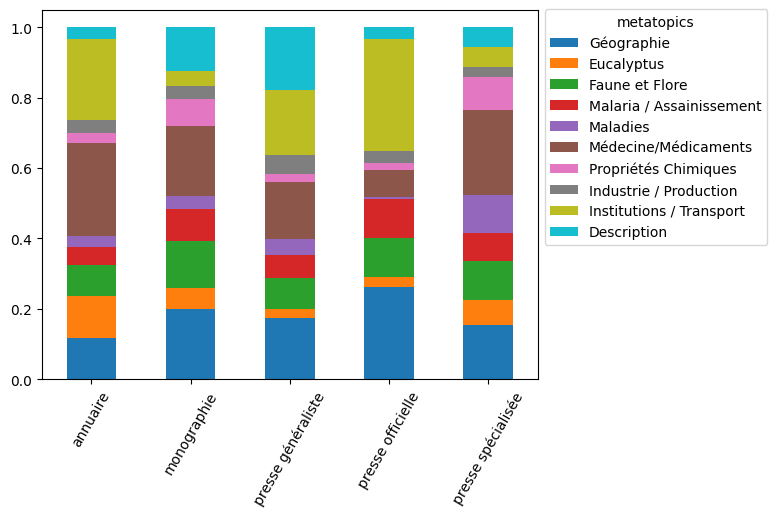

In [267]:
column_order = ['Géographie', 'Eucalyptus', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description']
plot_histogram(df, "type_clean", "metatopics", normalize=True, columns_to_remove=["Autres", "Erreurs"], column_order=column_order)

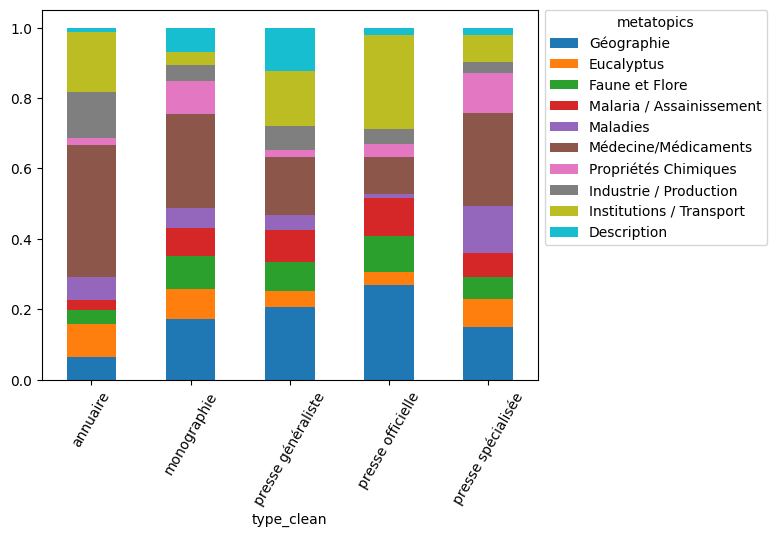

In [268]:
plot_histogram(df, "type_clean", "metatopics", weights="context", normalize=True, columns_to_remove=["Autres", "Erreurs"], column_order=column_order)

## 2.2) Topics and type of publication (old)

In [ ]:
pd.set_option('display.max_columns', 800)
exploded_df_topics = df.explode("topics").reset_index().drop("index", axis=1)
cross_tab = pd.crosstab(exploded_df_topics.type_clean, exploded_df_topics.topics, margins=True)
cross_tab

topics,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,All
type_clean,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
annuaire,0,45,20,11,12,13,11,2,4,8,2,13,3,9,6,7,3,5,2,19,67,7,44,0,10,0,0,1,28,0,1,35,1,6,0,4,0,0,0,1,1,0,2,5,11,7,40,1,1,3,0,0,4,0,8,4,1,1,0,4,10,30,0,4,3,0,0,5,78,0,3,1,25,8,1,0,98,2,5,12,66,1,3,0,0,0,0,0,2,35,0,0,0,2,0,2,3,1,37,0,0,3,6,0,1,1,2,1,0,0,4,9,5,0,1,3,1,0,8,0,0,0,2,977
monographie,4,3050,941,1009,517,444,340,528,371,357,398,439,275,331,353,27,282,406,362,66,22,313,286,231,155,26,243,15,264,97,144,90,320,74,256,320,12,128,230,21,43,4,352,72,189,111,18,75,23,88,123,156,396,16,23,59,169,249,129,239,34,25,42,73,165,28,29,207,20,16,52,109,747,9,88,102,13,61,23,56,11,234,164,58,67,25,164,15,13,48,65,63,4,16,2,130,248,118,49,6,57,22,128,166,81,161,29,61,5,73,19,21,48,50,76,61,48,13,60,55,0,32,124,21070
presse généraliste,2,2595,778,508,557,160,108,122,188,190,294,393,194,102,321,46,72,59,26,139,221,23,45,172,276,11,108,284,131,93,134,89,87,128,59,169,7,18,125,261,273,3,15,193,11,42,164,13,190,107,38,9,82,17,166,244,3,60,14,40,131,111,18,34,165,11,137,35,201,227,81,19,113,17,52,25,63,69,80,20,101,74,56,49,4,18,14,2,145,31,41,25,14,113,0,27,145,20,153,1,16,67,111,31,15,12,25,38,16,66,93,509,185,11,36,30,76,18,141,5,1,51,94,15268
presse officielle,2,286,302,51,96,60,22,81,94,48,91,54,28,38,74,3,45,4,9,70,8,17,3,27,109,0,4,52,34,16,11,5,16,23,13,43,1,0,12,7,6,225,1,26,5,5,19,1,25,18,8,2,14,1,3,21,0,21,4,0,11,30,4,15,6,1,0,2,6,3,5,3,49,228,7,4,2,13,115,0,3,5,5,67,8,1,1,2,0,1,4,5,3,12,0,11,25,3,1,1,2,5,17,30,1,5,3,3,0,3,0,27,24,4,32,1,5,3,12,1,1,2,4,3111
presse spécialisée,3,1228,905,548,648,310,367,294,281,211,454,438,210,245,292,453,263,254,176,487,65,124,157,339,207,309,147,179,177,160,148,82,180,99,180,377,288,222,271,16,10,1,245,169,95,86,44,346,30,219,133,130,175,179,49,268,184,100,70,99,28,15,152,218,95,136,18,140,6,22,40,48,560,4,41,193,24,56,14,34,11,133,75,109,81,106,102,62,10,24,65,58,111,6,116,76,247,50,24,76,30,44,191,46,47,72,9,204,65,62,3,28,20,115,97,51,29,57,51,7,57,34,80,19211
All,11,7204,2946,2127,1830,987,848,1027,938,814,1239,1337,710,725,1046,536,665,728,575,781,383,484,535,769,757,346,502,531,634,366,438,301,604,330,508,913,308,368,638,306,333,233,615,465,311,251,285,436,269,435,302,297,671,213,249,596,357,431,217,382,214,211,216,344,434,176,184,389,311,268,181,180,1494,266,189,324,200,201,237,122,192,447,303,283,160,150,281,81,170,139,175,151,132,149,118,246,668,192,264,84,105,141,453,273,145,251,68,307,86,204,119,594,282,180,242,146,159,91,272,68,59,119,304,59637


<Axes: xlabel='type_clean'>

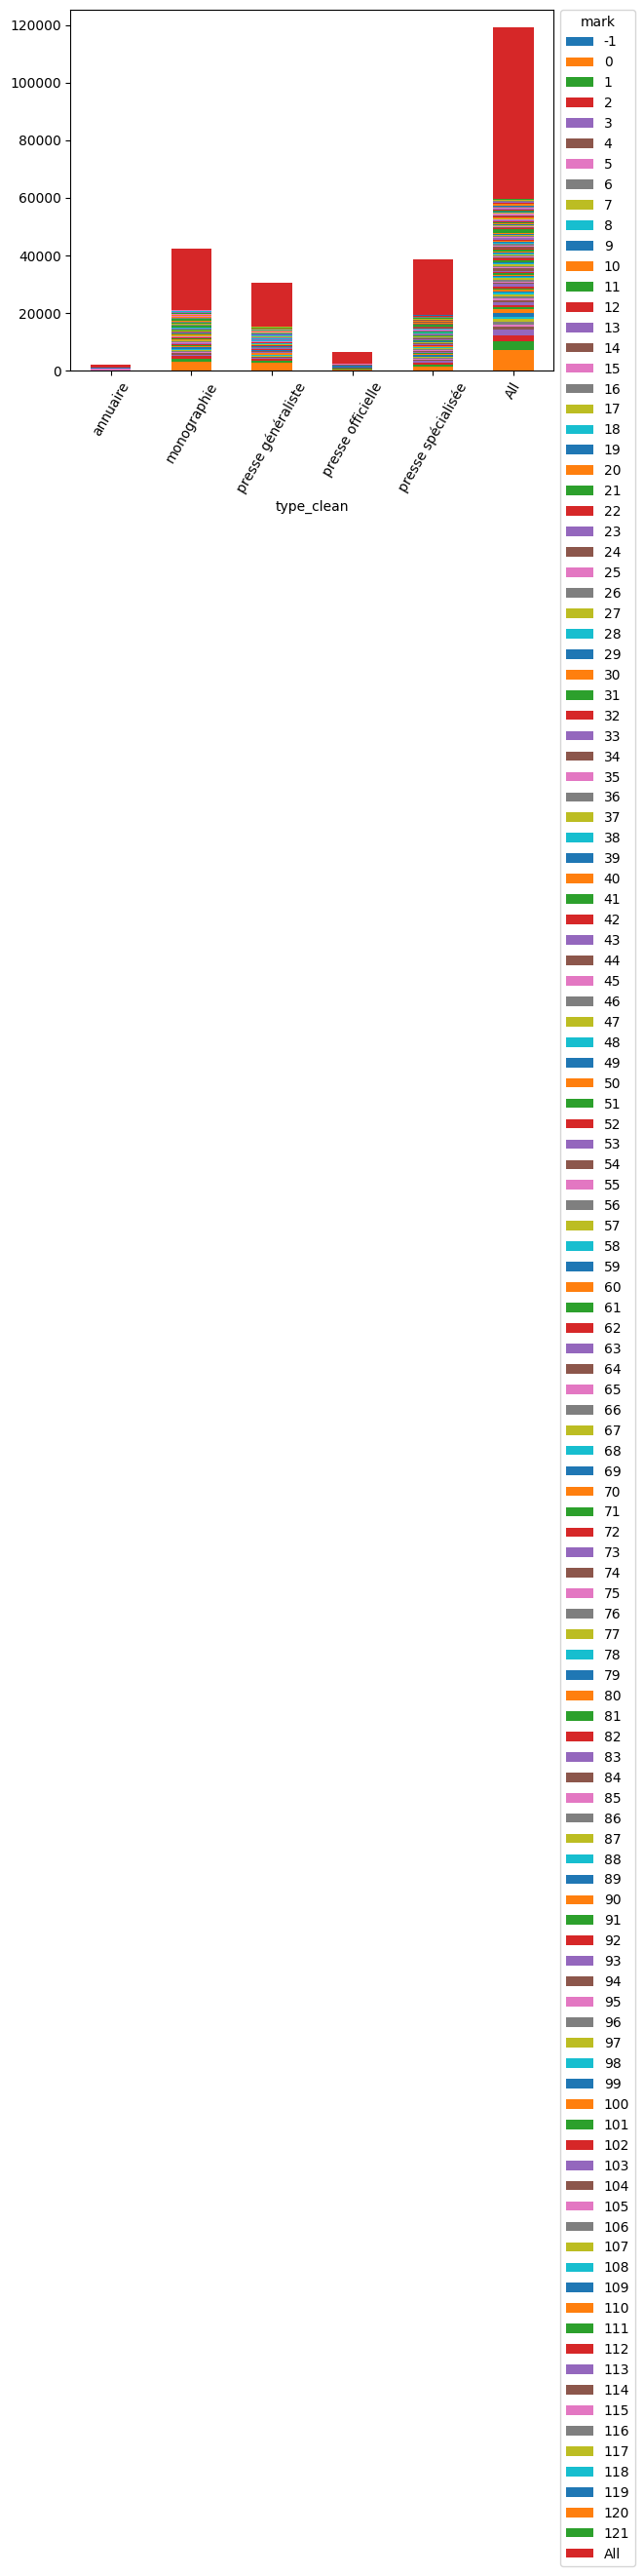

In [ ]:
ax = cross_tab.plot(kind='bar', stacked=True, rot=0)
ax.legend(title='mark', bbox_to_anchor=(1, 1.02), loc='upper left')
plt.xticks(rotation=60)
ax

In [ ]:
pd.set_option('display.max_columns', 100)
exploded_df_metatopics = df.explode("metatopics").reset_index().drop("index", axis=1)
cross_tab_metatopics = pd.crosstab(exploded_df_metatopics.type_clean, exploded_df_metatopics.metatopics)
cross_tab_metatopics

metatopics,Autres,Erreurs,Eucalyptus,Faune et Flore,Géographie,Industrie / Production,Institutions / Transport,Maladies,Malaria / Assainissement,Médecine/Médicaments,Propriétés Chimiques,Sensations,Unités de mesure
type_clean,,,,,,,,,,,,,
annuaire,120,107,45,58,41,75,141,54,25,271,24,0,16
monographie,1943,2073,1216,4334,2234,528,408,997,1441,3478,1571,243,604
presse généraliste,2694,700,397,3268,1633,478,1205,583,1121,2230,293,108,558
presse officielle,439,252,69,418,610,82,451,30,342,242,112,4,60
presse spécialisée,2405,1564,947,2107,1793,378,885,2264,1310,3115,1763,147,533


<Axes: xlabel='type_clean'>

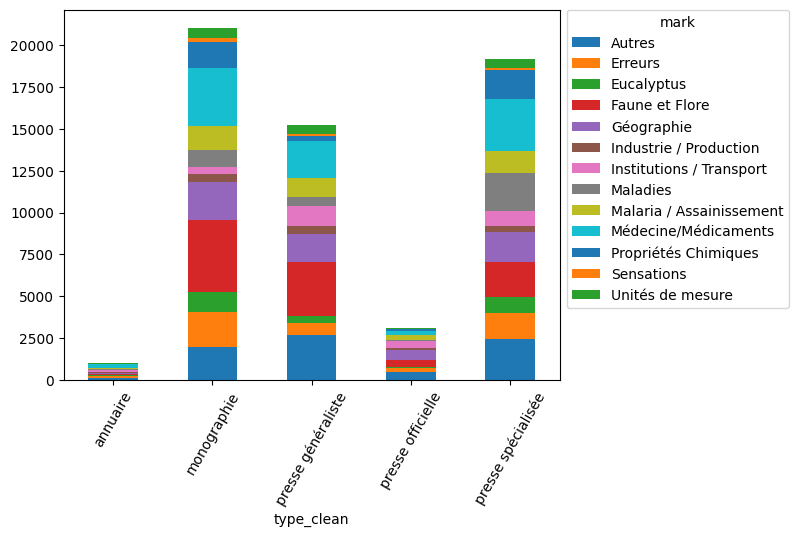

In [ ]:
ax = cross_tab_metatopics.plot(kind='bar', stacked=True, rot=0)
ax.legend(title='mark', bbox_to_anchor=(1, 1.02), loc='upper left')
plt.xticks(rotation=60)
ax

In [ ]:
pd.set_option('display.max_columns', 100)
exploded_df_metatopics = df.explode("metatopics").reset_index().drop("index", axis=1)
cross_tab_metatopics = pd.crosstab(exploded_df_metatopics.type_clean, exploded_df_metatopics.metatopics, normalize="index")
cross_tab_metatopics

metatopics,Autres,Erreurs,Eucalyptus,Faune et Flore,Géographie,Industrie / Production,Institutions / Transport,Maladies,Malaria / Assainissement,Médecine/Médicaments,Propriétés Chimiques,Sensations,Unités de mesure
type_clean,,,,,,,,,,,,,
annuaire,0.122825,0.109519,0.046059,0.059365,0.041965,0.076766,0.144319,0.055271,0.025589,0.277380,0.024565,0.000000,0.016377
monographie,0.092216,0.098386,0.057712,0.205695,0.106028,0.025059,0.019364,0.047318,0.068391,0.165069,0.074561,0.011533,0.028666
presse généraliste,0.176447,0.045848,0.026002,0.214042,0.106956,0.031307,0.078923,0.038184,0.073422,0.146057,0.019190,0.007074,0.036547
presse officielle,0.141112,0.081003,0.022179,0.134362,0.196078,0.026358,0.144969,0.009643,0.109932,0.077788,0.036001,0.001286,0.019286
presse spécialisée,0.125189,0.081412,0.049295,0.109677,0.093332,0.019676,0.046067,0.117849,0.068190,0.162147,0.091770,0.007652,0.027745


<Axes: xlabel='type_clean'>

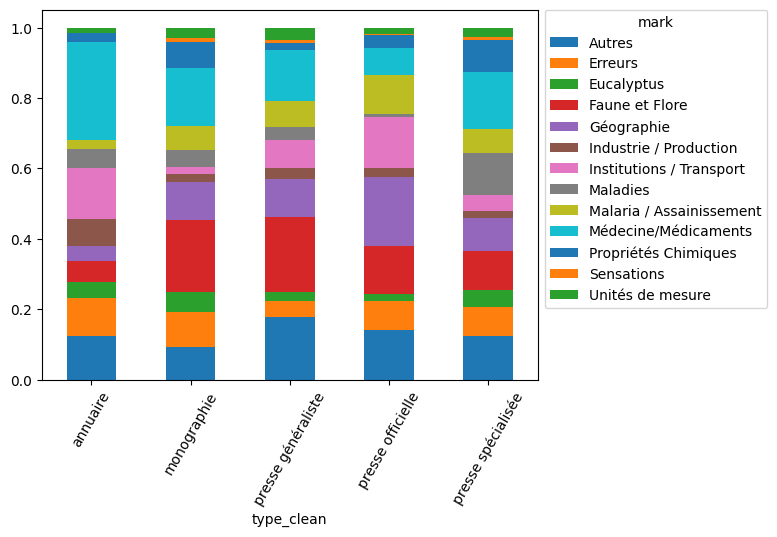

In [ ]:
ax = cross_tab_metatopics.plot(kind='bar', stacked=True, rot=0)
ax.legend(title='mark', bbox_to_anchor=(1, 1.02), loc='upper left')
plt.xticks(rotation=60)
ax

In [ ]:
pd.set_option('display.max_columns', 100)
exploded_df_metatopics = df.explode("metatopics").reset_index().drop("index", axis=1)
exploded_df_metatopics = exploded_df_metatopics[exploded_df_metatopics["metatopics"].isin(["Autres", "Erreurs"]) == False]
cross_tab_metatopics = pd.crosstab(exploded_df_metatopics.type_clean, exploded_df_metatopics.metatopics, normalize="index")
cross_tab_metatopics

metatopics,Eucalyptus,Faune et Flore,Géographie,Industrie / Production,Institutions / Transport,Maladies,Malaria / Assainissement,Médecine/Médicaments,Propriétés Chimiques,Sensations,Unités de mesure
type_clean,,,,,,,,,,,
annuaire,0.060000,0.077333,0.054667,0.100000,0.188000,0.072000,0.033333,0.361333,0.032000,0.000000,0.021333
monographie,0.071303,0.254134,0.130996,0.030960,0.023924,0.058461,0.084496,0.203940,0.092119,0.014249,0.035417
presse généraliste,0.033434,0.275223,0.137527,0.040256,0.101482,0.049099,0.094408,0.187805,0.024676,0.009096,0.046993
presse officielle,0.028512,0.172727,0.252066,0.033884,0.186364,0.012397,0.141322,0.100000,0.046281,0.001653,0.024793
presse spécialisée,0.062131,0.138236,0.117635,0.024800,0.058063,0.148537,0.085947,0.204370,0.115667,0.009644,0.034969


<Axes: xlabel='type_clean'>

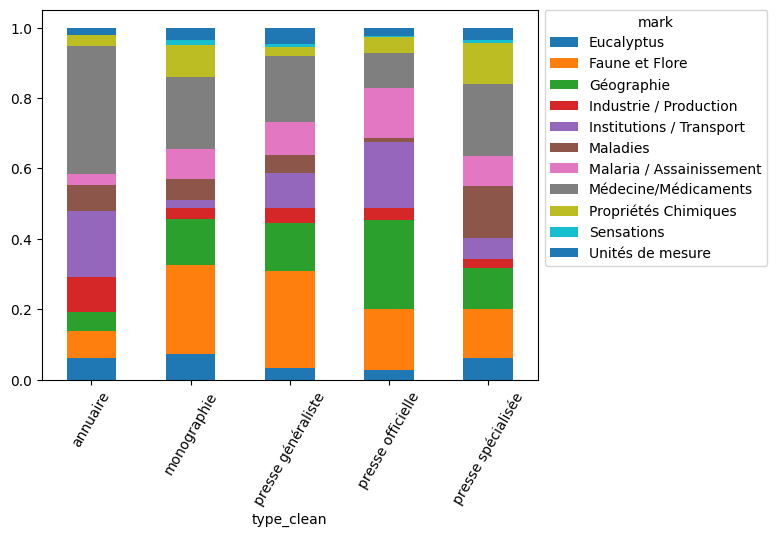

In [ ]:
ax = cross_tab_metatopics.plot(kind='bar', stacked=True, rot=0)
ax.legend(title='mark', bbox_to_anchor=(1, 1.02), loc='upper left')
plt.xticks(rotation=60)
ax

## 2.3) Topics and time

In [ ]:
docs_year = [df.loc[df['ark'] == ark, "date_clean"].iloc[0] for ark in docs_ark]

In [ ]:
topics_over_time = topic_model.topics_over_time(docs_text, docs_year, nr_bins=60)

In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

<Axes: xlabel='date_clean'>

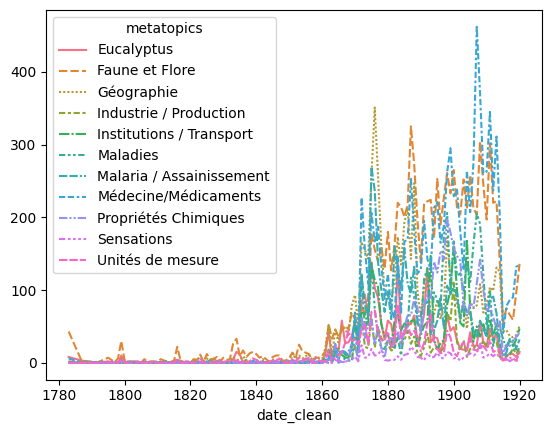

In [ ]:
exploded_df_metatopics = df.explode("metatopics").reset_index().drop("index", axis=1)
exploded_df_metatopics = exploded_df_metatopics[exploded_df_metatopics["metatopics"].isin(["Autres", "Erreurs"]) == False]
cross_tab_metatopics = pd.crosstab(exploded_df_metatopics.date_clean, exploded_df_metatopics.metatopics)
sns.lineplot(cross_tab_metatopics)

# 2.4) Topic co-occurrence network

In [314]:
co_occurrences = df["topics"].to_list()
co_occurrences = [list(set(occ)) for occ in co_occurrences if len(set(occ)) > 1]
co_occurrences = [list(itertools.combinations(occ, 2)) for occ in co_occurrences]
co_occurrences = list(itertools.chain.from_iterable(co_occurrences))
co_occurrences = Counter(co_occurrences)
co_occurrences = [(occ[0][0], occ[0][1], occ[1]) for occ in co_occurrences.most_common()]
co_occurrences

[(0, 10, 285),
 (0, 8, 264),
 (1, 3, 255),
 (0, 1, 253),
 (0, 3, 247),
 (1, 10, 239),
 (8, 10, 211),
 (0, 23, 207),
 (0, 2, 201),
 (3, 10, 199),
 (3, 8, 198),
 (1, 8, 194),
 (3, 14, 187),
 (0, 134, 183),
 (1, 2, 177),
 (0, 14, 167),
 (10, 23, 163),
 (1, 14, 162),
 (8, 14, 162),
 (8, 23, 160),
 (2, 8, 159),
 (1, 134, 154),
 (3, 134, 154),
 (2, 134, 150),
 (0, 39, 147),
 (2, 10, 147),
 (2, 3, 146),
 (1, 39, 146),
 (1, 23, 146),
 (0, 5, 144),
 (0, 83, 143),
 (3, 23, 142),
 (2, 102, 139),
 (3, 9, 139),
 (2, 5, 139),
 (1, 35, 137),
 (10, 14, 136),
 (2, 14, 135),
 (3, 39, 134),
 (2, 23, 130),
 (5, 134, 128),
 (134, 14, 128),
 (1, 9, 127),
 (134, 8, 127),
 (134, 23, 125),
 (0, 9, 123),
 (1, 26, 123),
 (0, 51, 121),
 (134, 10, 121),
 (0, 56, 120),
 (3, 83, 120),
 (10, 83, 119),
 (14, 23, 119),
 (3, 35, 116),
 (1, 83, 115),
 (6, 13, 115),
 (1, 15, 114),
 (0, 35, 111),
 (8, 15, 110),
 (0, 102, 110),
 (2, 39, 110),
 (1, 5, 109),
 (1, 49, 109),
 (3, 15, 109),
 (8, 83, 109),
 (3, 5, 108),
 (3, 26, 

In [319]:
G = nx.Graph()

G.add_weighted_edges_from(co_occurrences)

In [320]:
nx.write_gexf(G, "test_network.gexf")